# Channel Importance Analysis — Multi-Channel ShallowCNN

Three complementary methods to identify which of the 12 input channels actually drive layer classification:

| Method | What it measures | Cost |
|---|---|---|
| **1. First-layer weight norm** | How strongly each channel is "attended" by the first conv layer | Free (reads trained weights) |
| **2. Channel ablation** | Accuracy drop when a single channel is zeroed on the test set | 12 forward passes, no retraining |
| **3. Gradient × Input saliency** | Full-network attribution — how much each channel/timestep causally influences the prediction | 1 backward pass per batch |

The model and data setup is identical to `CNN_multichannel.ipynb` (ShallowCNN, 12-channel input, neuron-level train/test split).

In [1]:
%reload_ext autoreload
%autoreload 2

import sys, os, warnings, importlib, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score, accuracy_score

import microns_datacleaner as mic
import microns_datacleaner.filters as fl

warnings.filterwarnings('ignore')
np.random.seed(42)

def _find_root():
    p = Path.cwd()
    while p != p.parent:
        if (p / 'microns.h5').exists():
            return p
        p = p.parent
    p = Path.cwd()
    while p != p.parent:
        if (p / 'data' / '1718' / 'raw').exists():
            return p
        p = p.parent
    raise RuntimeError('Cannot find workspace root.')

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
TOMMY_DIR = Path('..').resolve()
if str(TOMMY_DIR) not in sys.path:
    sys.path.insert(0, str(TOMMY_DIR))

print(f'Workspace root: {ROOT}')

Workspace root: c:\Users\tomma\Desktop\NEUROSCIENCE


## Data loading

In [2]:
cleaner = mic.MicronsDataCleaner(
    datadir=os.path.relpath(str(ROOT / 'data')),
    version=1718,
    download_policy='minimum',
)
units_match, _ = cleaner.process_nucleus_data(functional_data='match')

matched = fl.filter_neurons(
    units_match,
    tuning='matched',
    cell_type='excitatory_neuron',
    brain_area='V1',
).copy()

unit_id_col = None
for col_name in ['functional_unit_id', 'unit_id', 'index', 'neuron_idx', 'neuron_id']:
    if col_name in matched.columns:
        unit_id_col = col_name
        break
if unit_id_col is None:
    raise ValueError(f'No usable neuron index column. Available: {list(matched.columns)}')

print(f'Matched V1 excitatory neurons: {len(matched)}')
print(matched['layer'].value_counts(dropna=False).sort_index())

Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 60172.74it/s]


Matched V1 excitatory neurons: 13044
layer
L1        16
L2/3    6340
L4      3941
L5      2269
L6       478
Name: count, dtype: int64


In [3]:
from reader import MicronsReader

H5_CANDIDATES = [
    ROOT / 'microns.h5',
    ROOT / 'data' / 'functional' / 'microns_functional.h5',
]
functional_path = next((p for p in H5_CANDIDATES if p.exists()), None)
if functional_path is None:
    raise FileNotFoundError(f'No functional H5 found. Tried: {H5_CANDIDATES}')

funcreader   = MicronsReader(str(functional_path))
session_keys = list(funcreader.f['sessions'].keys())

scan_rows = []
for k in session_keys:
    parts = k.split('_')
    if len(parts) == 2:
        try:
            scan_rows.append((int(parts[0]), int(parts[1]), k))
        except ValueError:
            pass

scan_df = (
    pd.DataFrame(scan_rows, columns=['session', 'scan_idx', 'key'])
    .sort_values(['session', 'scan_idx'])
    .reset_index(drop=True)
)
print(f'Session/scan keys available: {len(scan_df)}')

Session/scan keys available: 14


## Helper functions

In [4]:
def zscore_1d(x, eps=1e-8):
    x = np.asarray(x, dtype=np.float32)
    m, s = np.nanmean(x), np.nanstd(x)
    if not np.isfinite(s) or s < eps:
        return np.zeros_like(x)
    return (x - m) / (s + eps)


def resample_to(arr, target_len):
    arr = np.asarray(arr, dtype=np.float32).ravel()
    if arr.size == target_len:
        return arr
    return np.interp(
        np.linspace(0, 1, target_len),
        np.linspace(0, 1, arr.size),
        arr,
    ).astype(np.float32)


def extract_stim_channels(clip, target_len):
    frames = clip.astype(np.float32)
    if frames.ndim != 3:
        return np.zeros((7, target_len), dtype=np.float32)
    F, H, W = frames.shape
    eps = 1e-8
    pix = frames.reshape(F, -1)
    mean_intensity = pix.mean(axis=1)
    std_intensity  = pix.std(axis=1)
    if F > 1:
        d = np.abs(np.diff(frames, axis=0))
        motion_energy = np.concatenate([[0.0], d.reshape(F - 1, -1).mean(axis=1)])
    else:
        motion_energy = np.zeros(F, dtype=np.float32)
    grad_energy   = np.zeros(F, dtype=np.float32)
    edge_fraction = np.zeros(F, dtype=np.float32)
    for i in range(F):
        gy, gx = np.gradient(frames[i])
        gm = np.sqrt(gx**2 + gy**2)
        grad_energy[i]   = gm.mean()
        edge_fraction[i] = (gm > np.percentile(gm, 85)).mean()
    h0, h1 = H // 4, (3 * H) // 4
    w0, w1 = W // 4, (3 * W) // 4
    center = frames[:, h0:h1, w0:w1]
    center_mean  = center.reshape(F, -1).mean(axis=1)
    surround_n   = (H * W) - ((h1 - h0) * (w1 - w0))
    surround_mean = (pix.sum(axis=1) - center.reshape(F, -1).sum(axis=1)) / max(surround_n, 1)
    center_surround = center_mean - surround_mean
    norm_contrast   = std_intensity / (mean_intensity + eps)
    raw_channels = [
        mean_intensity, std_intensity, motion_energy,
        grad_energy, edge_fraction, center_surround, norm_contrast,
    ]
    result = np.zeros((7, target_len), dtype=np.float32)
    for i, ch in enumerate(raw_channels):
        result[i] = zscore_1d(resample_to(ch, target_len))
    return result


def extract_behaviour_channels(trial, target_len):
    result   = np.zeros((4, target_len), dtype=np.float32)
    treadmill = np.asarray(trial['treadmill'], dtype=np.float32).ravel()
    treadmill = np.where(np.isfinite(treadmill), treadmill, 0.0)
    result[0] = zscore_1d(resample_to(treadmill, target_len))
    pupil = np.asarray(trial['pupil'], dtype=np.float32)
    if pupil.ndim == 2:
        if pupil.shape[1] == 3:
            pupil = pupil.T
        if pupil.shape[0] >= 3:
            for i in range(3):
                ch = np.where(np.isfinite(pupil[i]), pupil[i], 0.0)
                result[1 + i] = zscore_1d(resample_to(ch, target_len))
    elif pupil.ndim == 1 and pupil.size > 0:
        ch = np.where(np.isfinite(pupil), pupil, 0.0)
        result[3] = zscore_1d(resample_to(ch, target_len))
    return result

## Build dataset

In [5]:
MAX_TRIALS_PER_SCAN = 8
MIN_TRACE_LEN       = 60
TARGET_LEN          = 300
N_CHANNELS          = 12
EXCLUDE_LAYERS      = {'L1'}

STIM_CHANNEL_NAMES = [
    'stim_mean', 'stim_std', 'stim_motion',
    'stim_grad', 'stim_edge_frac', 'stim_center_surround', 'stim_norm_contrast',
]
BEH_CHANNEL_NAMES  = ['treadmill', 'pupil_x', 'pupil_y', 'pupil_size']
CHANNEL_NAMES      = ['neural_response'] + STIM_CHANNEL_NAMES + BEH_CHANNEL_NAMES

# Channel group colour coding used in all plots
CHANNEL_COLORS = (
    ['#2166ac'] +                    # neural
    ['#d6604d'] * 7 +                # stimulus
    ['#4dac26'] * 4                  # behaviour
)

neuron_key_col = 'target_id' if 'target_id' in matched.columns else unit_id_col
print(f'Neuron identity column: {neuron_key_col}')

neuron_records = {}
clip_cache     = {}

matched_scans = matched[['session', 'scan_idx']].dropna().drop_duplicates().copy()
matched_scans['session']  = matched_scans['session'].astype(int)
matched_scans['scan_idx'] = matched_scans['scan_idx'].astype(int)

scan_candidates = (
    scan_df.merge(matched_scans, on=['session', 'scan_idx'], how='inner')
    .sort_values(['session', 'scan_idx'])
    .reset_index(drop=True)
)

for _, srow in scan_candidates.iterrows():
    session  = int(srow['session'])
    scan_idx = int(srow['scan_idx'])
    key      = srow['key']

    session_neurons = matched[
        (matched['session'] == session) & (matched['scan_idx'] == scan_idx)
    ].copy()
    session_neurons = session_neurons.dropna(subset=[unit_id_col, 'layer', neuron_key_col])
    session_neurons['layer'] = session_neurons['layer'].astype(str)
    session_neurons = session_neurons[~session_neurons['layer'].isin(EXCLUDE_LAYERS)]
    if session_neurons.empty:
        continue

    hashes = funcreader.get_hashes_by_session(key)
    if len(hashes) == 0:
        continue

    unit_ids       = funcreader.f[f'sessions/{key}/meta/unit_ids'][:]
    unit_id_to_row = {int(u): idx for idx, u in enumerate(unit_ids)}
    n_trials       = min(len(hashes), MAX_TRIALS_PER_SCAN)

    for t in range(n_trials):
        try:
            td = funcreader.get_trial(key, t)
        except (ValueError, KeyError):
            continue
        if td is None:
            continue

        cond_hash = hashes[t]
        if cond_hash not in clip_cache:
            clip, _ = funcreader.get_video_data(cond_hash)
            clip_cache[cond_hash] = extract_stim_channels(clip, TARGET_LEN) if clip is not None else None

        stim_channels = clip_cache[cond_hash]
        beh_channels  = extract_behaviour_channels(td, TARGET_LEN)
        responses     = td['responses']

        for _, nr in session_neurons.iterrows():
            neuron_key = int(nr[neuron_key_col])
            if neuron_key in neuron_records:
                continue
            layer   = str(nr['layer'])
            fuid    = int(nr[unit_id_col])
            row_idx = unit_id_to_row.get(fuid)
            if row_idx is None or row_idx >= responses.shape[0]:
                continue
            trace = np.asarray(responses[row_idx, :], dtype=np.float32).ravel()
            trace = trace[np.isfinite(trace)]
            if trace.size < MIN_TRACE_LEN:
                continue
            trace = zscore_1d(resample_to(trace, TARGET_LEN))
            multichan = np.zeros((N_CHANNELS, TARGET_LEN), dtype=np.float32)
            multichan[0] = trace
            if stim_channels is not None:
                multichan[1:8] = stim_channels
            multichan[8:12] = beh_channels
            neuron_records[neuron_key] = {
                'neuron_key': neuron_key, 'layer': layer,
                'multichan': multichan, 'unit_id': fuid,
            }

records = list(neuron_records.values())
print(f'Unique neuron samples: {len(records)}')
print(pd.Series([r['layer'] for r in records]).value_counts().sort_index())

Neuron identity column: functional_unit_id
Unique neuron samples: 6548
L2/3    2704
L4      2072
L5      1425
L6       347
Name: count, dtype: int64


## Train / test split

In [6]:
neuron_df = pd.DataFrame(
    [{'neuron_key': r['neuron_key'], 'layer': r['layer']} for r in records]
).drop_duplicates(subset=['neuron_key'])

layer_counts = neuron_df['layer'].value_counts()
keep_layers  = layer_counts[layer_counts >= 20].index.tolist()
neuron_df    = neuron_df[neuron_df['layer'].isin(keep_layers)].copy()

TARGET_TRAIN_SAMPLES = 6000
test_size    = 0.25
total_target = int(round(TARGET_TRAIN_SAMPLES / (1 - test_size)))
if len(neuron_df) > total_target:
    _, neuron_df = train_test_split(
        neuron_df, train_size=total_target, random_state=42,
        stratify=neuron_df['layer'].values,
    )
    neuron_df = neuron_df.reset_index(drop=True)

train_neurons, test_neurons = train_test_split(
    neuron_df['neuron_key'].values, test_size=test_size,
    random_state=42, stratify=neuron_df['layer'].values,
)
train_set = set(train_neurons)
test_set  = set(test_neurons)

enc = LabelEncoder()
enc.fit(neuron_df['layer'])

def build_split(neuron_keys_set):
    X, y, uids = [], [], []
    for r in records:
        if r['neuron_key'] not in neuron_keys_set or r['layer'] not in keep_layers:
            continue
        X.append(r['multichan'])
        y.append(r['layer'])
        uids.append(r['neuron_key'])
    return np.asarray(X, dtype=np.float32), enc.transform(y), np.array(uids)

X_train, y_train, uids_train = build_split(train_set)
X_test,  y_test,  uids_test  = build_split(test_set)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (4911, 12, 300) | Test: (1637, 12, 300)


## Model definition & training

In [7]:
if importlib.util.find_spec('torch') is None:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '--quiet', 'torch',
        '--index-url', 'https://download.pytorch.org/whl/cpu',
    ])

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {DEVICE}')

n_classes    = len(enc.classes_)
class_counts = np.bincount(y_train, minlength=n_classes).astype(np.float32)
class_weights = torch.tensor(1.0 / (class_counts + 1e-8)).to(DEVICE)
class_weights /= class_weights.sum()

BATCH_SIZE = 128

def make_loader(X, y, shuffle):
    return DataLoader(
        TensorDataset(torch.tensor(X), torch.tensor(y, dtype=torch.long)),
        batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=False,
    )

train_loader = make_loader(X_train, y_train, shuffle=True)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)

PyTorch 2.11.0+cpu | device: cpu


In [8]:
class MultiChannelShallowCNN(nn.Module):
    def __init__(self, in_channels, seq_len, n_classes, dropout=0.4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 64,  kernel_size=7, padding=3),
            nn.BatchNorm1d(64),  nn.ReLU(True), nn.MaxPool1d(2),
            nn.Conv1d(64,        128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(True), nn.MaxPool1d(2),
            nn.Conv1d(128,       256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(True), nn.MaxPool1d(2),
        )
        flat = 256 * (seq_len // 8)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 256), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.head(self.conv(x))


def train_model(model, train_loader, test_loader,
                lr=3e-4, weight_decay=1e-4, max_epochs=150, patience=15):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    opt       = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    best_loss, best_state, cnt = float('inf'), None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            criterion(model(xb), yb).backward()
            opt.step()
        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits    = model(xb)
                val_loss += criterion(logits, yb).item() * xb.size(0)
                correct  += (logits.argmax(1) == yb).sum().item()
        val_loss /= len(test_loader.dataset)
        val_acc   = correct / len(test_loader.dataset)
        scheduler.step()
        print(f'Epoch {epoch:3d} | val_loss={val_loss:.4f}  val_acc={val_acc:.3f}')
        if val_loss < best_loss:
            best_loss, best_state, cnt = val_loss, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            cnt += 1
            if cnt >= patience:
                print(f'Early stop at epoch {epoch}')
                break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print(f'Best val_loss: {best_loss:.4f}')


model = MultiChannelShallowCNN(N_CHANNELS, TARGET_LEN, n_classes).to(DEVICE)
train_model(model, train_loader, test_loader)

Epoch   1 | val_loss=1.0980  val_acc=0.344
Epoch   2 | val_loss=1.0921  val_acc=0.411
Epoch   3 | val_loss=1.0834  val_acc=0.379
Epoch   4 | val_loss=1.0758  val_acc=0.354
Epoch   5 | val_loss=1.0794  val_acc=0.383
Epoch   6 | val_loss=1.0656  val_acc=0.417
Epoch   7 | val_loss=1.0706  val_acc=0.406
Epoch   8 | val_loss=1.0530  val_acc=0.381
Epoch   9 | val_loss=1.0586  val_acc=0.428
Epoch  10 | val_loss=1.0731  val_acc=0.453
Epoch  11 | val_loss=1.0532  val_acc=0.459
Epoch  12 | val_loss=1.0318  val_acc=0.487
Epoch  13 | val_loss=0.9937  val_acc=0.497
Epoch  14 | val_loss=0.9436  val_acc=0.532
Epoch  15 | val_loss=0.9449  val_acc=0.586
Epoch  16 | val_loss=0.8306  val_acc=0.611
Epoch  17 | val_loss=0.7686  val_acc=0.642
Epoch  18 | val_loss=0.7278  val_acc=0.685
Epoch  19 | val_loss=0.6960  val_acc=0.686
Epoch  20 | val_loss=0.7274  val_acc=0.723
Epoch  21 | val_loss=0.6645  val_acc=0.744
Epoch  22 | val_loss=0.6480  val_acc=0.753
Epoch  23 | val_loss=0.6148  val_acc=0.761
Epoch  24 |

In [9]:
# Baseline balanced accuracy on full 12-channel test set
model.eval()
preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
y_pred_full = np.concatenate(preds)

baseline_bal_acc = balanced_accuracy_score(y_test, y_pred_full)
baseline_acc     = accuracy_score(y_test, y_pred_full)
print(f'Baseline | accuracy={baseline_acc:.3f}  balanced_accuracy={baseline_bal_acc:.3f}')

Baseline | accuracy=0.781  balanced_accuracy=0.790


---
# Method 1 — First-layer weight norm

The first conv layer has weights of shape **(64 filters × 12 channels × 7 kernel positions)**.
For each input channel `c` we compute the Frobenius norm across all filters and positions:

$$\text{norm}(c) = \sqrt{\sum_{f=0}^{63}\sum_{k=0}^{6} W[f,\,c,\,k]^2}$$

A high norm means that channel drives large activations out of the very first layer.
This is a *proxy* only — it does not account for later layers or non-linear interactions.

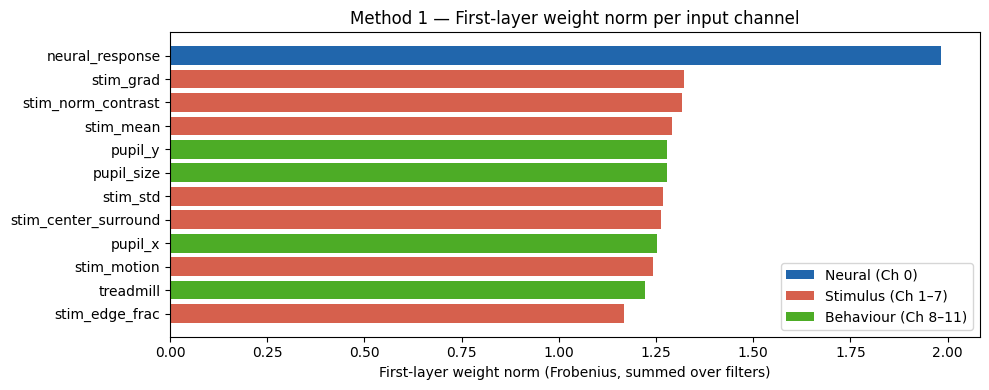

             channel  weight_norm
     neural_response     1.983954
           stim_grad     1.321764
  stim_norm_contrast     1.317794
           stim_mean     1.290277
             pupil_y     1.278957
          pupil_size     1.277038
            stim_std     1.268892
stim_center_surround     1.261454
             pupil_x     1.253113
         stim_motion     1.243360
           treadmill     1.221989
      stim_edge_frac     1.168240


In [10]:
first_conv    = model.conv[0]                          # Conv1d(12 → 64, k=7)
W             = first_conv.weight.detach().cpu().numpy()  # (64, 12, 7)
channel_norms = np.linalg.norm(W.reshape(W.shape[0], W.shape[1], -1), axis=(0, 2))
# shape: (12,) — Frobenius norm over filters and kernel positions per channel

norm_df = pd.DataFrame({'channel': CHANNEL_NAMES, 'weight_norm': channel_norms})
norm_df = norm_df.sort_values('weight_norm', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(
    norm_df['channel'], norm_df['weight_norm'],
    color=[CHANNEL_COLORS[CHANNEL_NAMES.index(c)] for c in norm_df['channel']],
)
ax.invert_yaxis()
ax.set_xlabel('First-layer weight norm (Frobenius, summed over filters)')
ax.set_title('Method 1 — First-layer weight norm per input channel')

# Legend for groups
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2166ac', label='Neural (Ch 0)'),
    Patch(facecolor='#d6604d', label='Stimulus (Ch 1–7)'),
    Patch(facecolor='#4dac26', label='Behaviour (Ch 8–11)'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print(norm_df.to_string(index=False))

---
# Method 2 — Channel ablation

Zero out one channel at a time in the test set (zeroing = mean after z-scoring, so it is equivalent to removing all information from that channel).  
Measure the drop in balanced accuracy relative to the full-model baseline — no retraining needed.

$$\Delta\text{BalAcc}(c) = \text{BalAcc}_{\text{full}} - \text{BalAcc}_{\text{channel } c \text{ zeroed}}$$

A large positive drop means the model depended heavily on that channel.

In [11]:
def ablate_channel(model, X, y, channel_idx):
    """Zero out one channel in X and return balanced accuracy."""
    X_abl = X.copy()
    X_abl[:, channel_idx, :] = 0.0
    loader = make_loader(X_abl, y, shuffle=False)
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return balanced_accuracy_score(y, np.concatenate(preds))


ablation_results = []
for c_idx, c_name in enumerate(CHANNEL_NAMES):
    abl_bal_acc = ablate_channel(model, X_test, y_test, c_idx)
    drop = baseline_bal_acc - abl_bal_acc
    ablation_results.append({'channel': c_name, 'ablated_bal_acc': abl_bal_acc, 'drop': drop})
    print(f'  Ch {c_idx:2d}  {c_name:<30s}  bal_acc={abl_bal_acc:.3f}  drop={drop:+.3f}')

ablation_df = (
    pd.DataFrame(ablation_results)
    .sort_values('drop', ascending=False)
    .reset_index(drop=True)
)
print(f'\nBaseline balanced accuracy: {baseline_bal_acc:.3f}')

  Ch  0  neural_response                 bal_acc=0.459  drop=+0.330
  Ch  1  stim_mean                       bal_acc=0.786  drop=+0.003
  Ch  2  stim_std                        bal_acc=0.776  drop=+0.014
  Ch  3  stim_motion                     bal_acc=0.772  drop=+0.018
  Ch  4  stim_grad                       bal_acc=0.775  drop=+0.014
  Ch  5  stim_edge_frac                  bal_acc=0.774  drop=+0.015
  Ch  6  stim_center_surround            bal_acc=0.777  drop=+0.013
  Ch  7  stim_norm_contrast              bal_acc=0.773  drop=+0.017
  Ch  8  treadmill                       bal_acc=0.778  drop=+0.011
  Ch  9  pupil_x                         bal_acc=0.782  drop=+0.008
  Ch 10  pupil_y                         bal_acc=0.780  drop=+0.009
  Ch 11  pupil_size                      bal_acc=0.776  drop=+0.014

Baseline balanced accuracy: 0.790


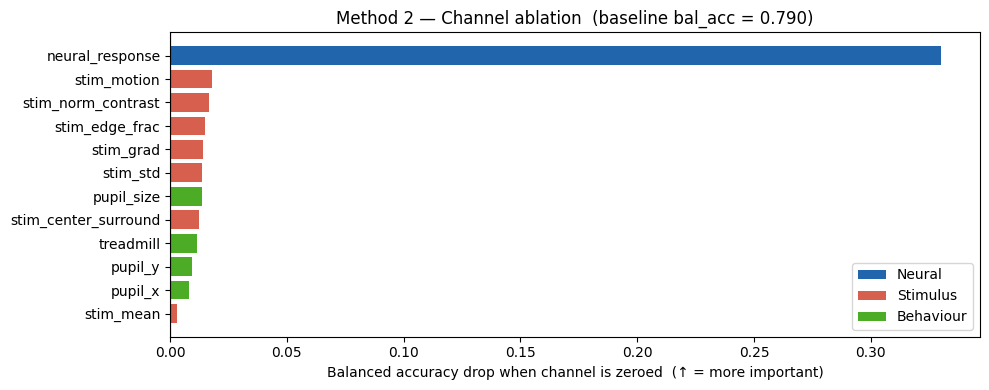

             channel  ablated_bal_acc     drop
     neural_response         0.459333 0.330217
         stim_motion         0.771745 0.017805
  stim_norm_contrast         0.772908 0.016642
      stim_edge_frac         0.774463 0.015087
           stim_grad         0.775395 0.014155
            stim_std         0.775753 0.013798
          pupil_size         0.775900 0.013650
stim_center_surround         0.776966 0.012584
           treadmill         0.778060 0.011490
             pupil_y         0.780161 0.009389
             pupil_x         0.781516 0.008034
           stim_mean         0.786482 0.003068


In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = [CHANNEL_COLORS[CHANNEL_NAMES.index(c)] for c in ablation_df['channel']]
ax.barh(ablation_df['channel'], ablation_df['drop'], color=bar_colors)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Balanced accuracy drop when channel is zeroed  (↑ = more important)')
ax.set_title(f'Method 2 — Channel ablation  (baseline bal_acc = {baseline_bal_acc:.3f})')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2166ac', label='Neural'),
    Patch(facecolor='#d6604d', label='Stimulus'),
    Patch(facecolor='#4dac26', label='Behaviour'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print(ablation_df[['channel', 'ablated_bal_acc', 'drop']].to_string(index=False))

### Group-level ablation

Zero out entire channel groups (neural / all stimulus / all behaviour) to see how much each group contributes in isolation.

  neural (0)                           bal_acc=0.459  drop=+0.330
  stimulus (1–7)                       bal_acc=0.539  drop=+0.250
  behaviour (8–11)                     bal_acc=0.734  drop=+0.056
  stim + beh (1–11)                    bal_acc=0.329  drop=+0.461
  neural + beh (0,8–11)                bal_acc=0.455  drop=+0.335
  neural + stim (0–7)                  bal_acc=0.354  drop=+0.435


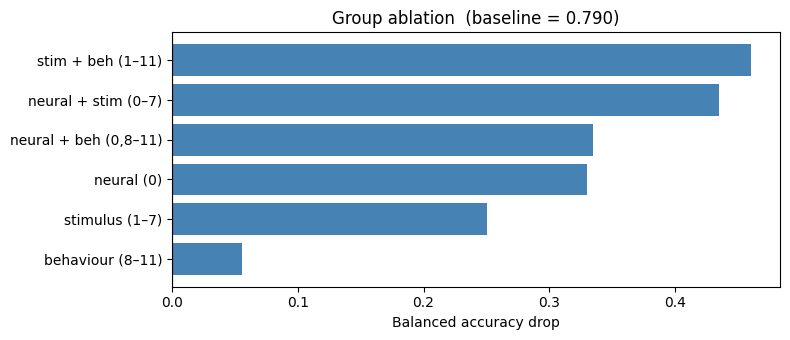

In [13]:
CHANNEL_GROUPS = {
    'neural (0)':       list(range(0, 1)),
    'stimulus (1–7)':   list(range(1, 8)),
    'behaviour (8–11)': list(range(8, 12)),
    'stim + beh (1–11)': list(range(1, 12)),
    'neural + beh (0,8–11)': [0] + list(range(8, 12)),
    'neural + stim (0–7)':   list(range(0, 8)),
}

group_results = []
for group_name, channels in CHANNEL_GROUPS.items():
    X_abl = X_test.copy()
    X_abl[:, channels, :] = 0.0
    loader = make_loader(X_abl, y_test, shuffle=False)
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    abl_ba = balanced_accuracy_score(y_test, np.concatenate(preds))
    group_results.append({'group_zeroed': group_name, 'bal_acc': abl_ba, 'drop': baseline_bal_acc - abl_ba})
    print(f'  {group_name:<35s}  bal_acc={abl_ba:.3f}  drop={baseline_bal_acc - abl_ba:+.3f}')

group_df = pd.DataFrame(group_results).sort_values('drop', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(group_df['group_zeroed'], group_df['drop'], color='steelblue')
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Balanced accuracy drop')
ax.set_title(f'Group ablation  (baseline = {baseline_bal_acc:.3f})')
plt.tight_layout()
plt.show()

---
# Method 3 — Gradient × Input saliency

For each test sample we compute the elementwise product of the input tensor with the gradient of the predicted class score w.r.t. the input:

$$\text{saliency}[c, t] = \left|\frac{\partial s_{\hat{y}}}{\partial x[c, t]}\right| \cdot |x[c, t]|$$

where $s_{\hat{y}}$ is the logit for the predicted class.  
Averaging over the test set gives a **(12 channels × 300 timesteps)** attribution map.

We then report:
1. **Per-channel importance** — the mean saliency aggregated over all timesteps
2. **Per-channel temporal profile** — heatmap of saliency over time for each channel (useful to see whether the attribution concentrates at stimulus onset, behavioural events, etc.)

In [14]:
model.eval()
saliency_sum   = np.zeros((N_CHANNELS, TARGET_LEN), dtype=np.float64)
saliency_count = 0

Xt = torch.tensor(X_test, dtype=torch.float32)
yt = torch.tensor(y_test, dtype=torch.long)

for start in range(0, len(Xt), BATCH_SIZE):
    xb = Xt[start:start + BATCH_SIZE].to(DEVICE)
    xb.requires_grad_(True)

    logits      = model(xb)                   # (B, n_classes)
    pred_class  = logits.argmax(dim=1)         # (B,)
    # Score for the predicted class of each sample
    score = logits[torch.arange(len(xb)), pred_class].sum()
    score.backward()

    with torch.no_grad():
        # Gradient × Input, absolute value
        sal = (xb.grad * xb).abs()             # (B, C, T)
        saliency_sum   += sal.cpu().numpy().sum(axis=0)   # (C, T)
        saliency_count += xb.size(0)

mean_saliency = saliency_sum / saliency_count   # (C, T)  — mean over test samples
channel_importance_grad = mean_saliency.mean(axis=1)  # (C,)  — mean over time

sal_df = pd.DataFrame({'channel': CHANNEL_NAMES, 'grad_x_input': channel_importance_grad})
sal_df = sal_df.sort_values('grad_x_input', ascending=False).reset_index(drop=True)
print(sal_df.to_string(index=False))

             channel  grad_x_input
     neural_response      0.057829
          pupil_size      0.014316
           stim_grad      0.013981
            stim_std      0.013832
  stim_norm_contrast      0.013277
           stim_mean      0.013191
stim_center_surround      0.012522
             pupil_x      0.012422
             pupil_y      0.011920
         stim_motion      0.011303
      stim_edge_frac      0.011171
           treadmill      0.008819


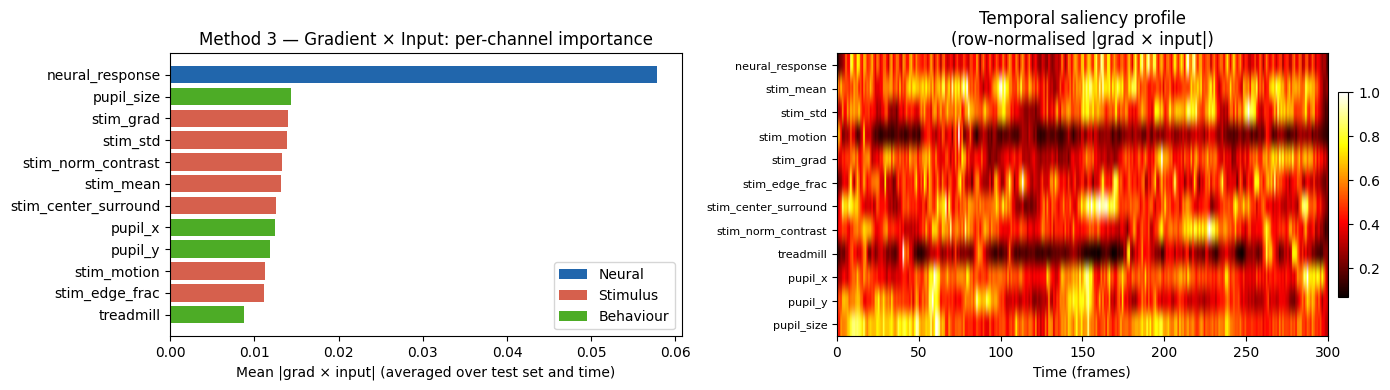

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: per-channel bar chart
ax = axes[0]
bar_colors = [CHANNEL_COLORS[CHANNEL_NAMES.index(c)] for c in sal_df['channel']]
ax.barh(sal_df['channel'], sal_df['grad_x_input'], color=bar_colors)
ax.invert_yaxis()
ax.set_xlabel('Mean |grad × input| (averaged over test set and time)')
ax.set_title('Method 3 — Gradient × Input: per-channel importance')
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2166ac', label='Neural'),
    Patch(facecolor='#d6604d', label='Stimulus'),
    Patch(facecolor='#4dac26', label='Behaviour'),
]
ax.legend(handles=legend_elements, loc='lower right')

# Right: temporal saliency heatmap  (C × T)
ax = axes[1]
# Normalise each channel to [0, 1] for visual clarity
row_max = mean_saliency.max(axis=1, keepdims=True) + 1e-12
heatmap = mean_saliency / row_max
im = ax.imshow(heatmap, aspect='auto', cmap='hot', origin='upper',
               extent=[0, TARGET_LEN, N_CHANNELS - 0.5, -0.5])
ax.set_yticks(range(N_CHANNELS))
ax.set_yticklabels(CHANNEL_NAMES, fontsize=8)
ax.set_xlabel('Time (frames)')
ax.set_title('Temporal saliency profile\n(row-normalised |grad × input|)')
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)

plt.tight_layout()
plt.show()

---
# Summary — all three methods side by side

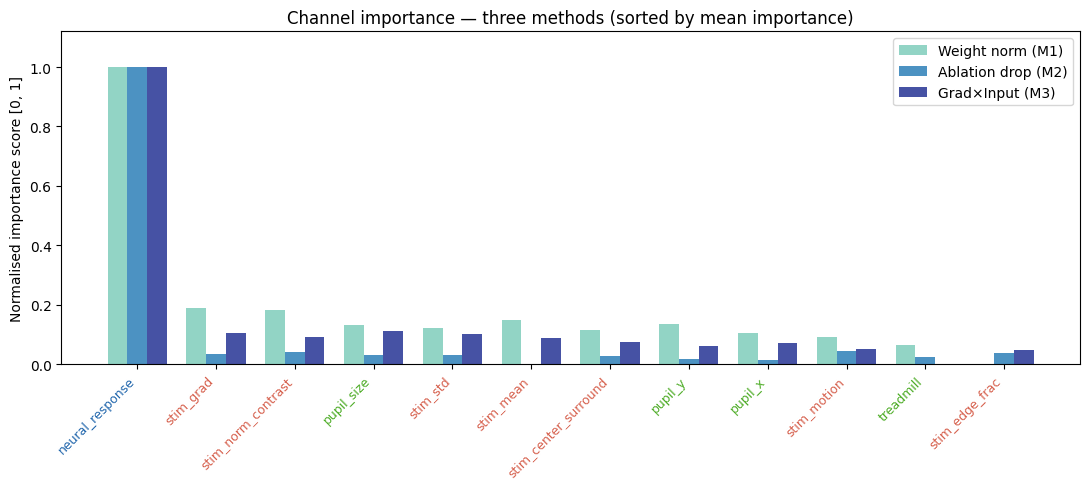


Ranking by mean normalised importance:
             channel  weight_norm  ablation_drop  grad_x_input  mean_importance
     neural_response        1.000          1.000         1.000            1.000
           stim_grad        0.188          0.034         0.105            0.109
  stim_norm_contrast        0.183          0.041         0.091            0.105
          pupil_size        0.133          0.032         0.112            0.093
            stim_std        0.123          0.033         0.102            0.086
           stim_mean        0.150          0.000         0.089            0.080
stim_center_surround        0.114          0.029         0.076            0.073
             pupil_y        0.136          0.019         0.063            0.073
             pupil_x        0.104          0.015         0.074            0.064
         stim_motion        0.092          0.045         0.051            0.063
           treadmill        0.066          0.026         0.000            0.031


In [16]:
# Normalise each method's scores to [0, 1] for a fair visual comparison
def norm01(v):
    v = np.array(v, dtype=float)
    lo, hi = v.min(), v.max()
    return (v - lo) / (hi - lo + 1e-12)

# Align all three series to the canonical CHANNEL_NAMES order
weight_norms_ordered   = np.array([channel_norms[CHANNEL_NAMES.index(c)] for c in CHANNEL_NAMES])
ablation_drops_ordered = np.array([ablation_df.set_index('channel').loc[c, 'drop'] for c in CHANNEL_NAMES])
grad_sal_ordered       = np.array([sal_df.set_index('channel').loc[c, 'grad_x_input'] for c in CHANNEL_NAMES])

summary_df = pd.DataFrame({
    'channel':      CHANNEL_NAMES,
    'weight_norm':  norm01(weight_norms_ordered),
    'ablation_drop':norm01(ablation_drops_ordered),
    'grad_x_input': norm01(grad_sal_ordered),
})
summary_df['mean_importance'] = summary_df[['weight_norm', 'ablation_drop', 'grad_x_input']].mean(axis=1)
summary_df = summary_df.sort_values('mean_importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 5))
x       = np.arange(N_CHANNELS)
width   = 0.25
channels_ordered = summary_df['channel'].tolist()
colors_ordered   = [CHANNEL_COLORS[CHANNEL_NAMES.index(c)] for c in channels_ordered]

b1 = ax.bar(x - width, summary_df['weight_norm'],   width, label='Weight norm (M1)',   alpha=0.85, color='#7fcdbb')
b2 = ax.bar(x,         summary_df['ablation_drop'], width, label='Ablation drop (M2)', alpha=0.85, color='#2c7fb8')
b3 = ax.bar(x + width, summary_df['grad_x_input'],  width, label='Grad×Input (M3)',    alpha=0.85, color='#253494')

# Colour x-tick labels by channel group
ax.set_xticks(x)
ax.set_xticklabels(channels_ordered, rotation=45, ha='right', fontsize=9)
for tick, c_name in zip(ax.get_xticklabels(), channels_ordered):
    tick.set_color(CHANNEL_COLORS[CHANNEL_NAMES.index(c_name)])

ax.set_ylabel('Normalised importance score [0, 1]')
ax.set_title('Channel importance — three methods (sorted by mean importance)')
ax.legend()
ax.set_ylim(0, 1.12)
plt.tight_layout()
plt.show()

print('\nRanking by mean normalised importance:')
print(summary_df[['channel', 'weight_norm', 'ablation_drop', 'grad_x_input', 'mean_importance']]
      .to_string(index=False, float_format=lambda x: f'{x:.3f}'))